In [92]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [93]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [94]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [96]:
df.drop("customerID", axis=1, inplace=True)

In [97]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [98]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [99]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 19)
y Shape: (7043,)


In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify=y ensures that the train-test split preserves the same proportion of classes in both 
# the training and testing datasets as the original dataset.

In [101]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [102]:
y_train.value_counts(normalize=True) * 100

Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

In [103]:
y_test.value_counts(normalize=True) * 100

Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64

In [104]:
num_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [105]:
cat_cols = X_train.select_dtypes(
    include="str"
).columns

cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [106]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_cols
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ]
)

In [108]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [109]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 30)
(1409, 30)


In [110]:
preprocessor.get_feature_names_out()

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__PaperlessBilling_Yes',
       'cat__PaymentMethod_Credit card (automatic)',
       'cat__PaymentMethod_Electronic check',
       '

In [111]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [112]:
lr = LogisticRegression(
    random_state=42
)

In [113]:
lr.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [114]:
y_pred = lr.predict(X_test_processed)

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))
print("classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8069552874378992
confusion_matrix:
 [[927 108]
 [164 210]]
classification report:
               precision    recall  f1-score   support

          No       0.85      0.90      0.87      1035
         Yes       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [29]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [31]:
y_pred_dt = dt.predict(X_test_processed)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("classification report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.7253371185237757
confusion_matrix:
 [[843 192]
 [195 179]]
classification report:
               precision    recall  f1-score   support

          No       0.81      0.81      0.81      1035
         Yes       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.72      1409



In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [36]:
y_pred_rf = rf.predict(X_test_processed)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("classification report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
confusion_matrix:
 [[921 114]
 [189 185]]
classification report:
               precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [116]:
from xgboost import XGBClassifier

In [117]:
y_train_xgb = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test_xgb = y_test.map({
    "No": 0,
    "Yes": 1
})

In [118]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [119]:
xgb.fit(
    X_train_processed,
    y_train_xgb
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_pred_xgb = xgb.predict(X_test_processed)

In [47]:
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("confusion_matrix:\n", confusion_matrix(y_test_xgb, y_pred_xgb))
print("classification report:\n", classification_report(y_test_xgb, y_pred_xgb))

Accuracy: 0.7721788502484032
confusion_matrix:
 [[902 133]
 [188 186]]
classification report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409



In [48]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__PaperlessBilling_Yes',
       'cat__PaymentMethod_Credit card (automatic)',
       'cat__PaymentMethod_Electronic check',
       '

In [49]:
coefficients = lr.coef_[0]

In [50]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df.head()

,Feature,Coefficient
0,num__SeniorCitizen,0.054651
1,num__tenure,-1.250481
2,num__MonthlyCharges,-0.470779
3,num__TotalCharges,0.523110
4,cat__gender_Male,0.022561


In [52]:
importance_df = importance_df.sort_values(
    by="Coefficient",
    ascending=False
)

importance_df

,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.182298
3,num__TotalCharges,0.523110
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065
26,cat__PaperlessBilling_Yes,0.371284
9,cat__MultipleLines_Yes,0.362275
29,cat__PaymentMethod_Mailed check,0.075442
0,num__SeniorCitizen,0.054651
17,cat__DeviceProtection_Yes,0.035237


In [53]:
importance_df.head(10)

,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.182298
3,num__TotalCharges,0.523110
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065
26,cat__PaperlessBilling_Yes,0.371284
9,cat__MultipleLines_Yes,0.362275
29,cat__PaymentMethod_Mailed check,0.075442
0,num__SeniorCitizen,0.054651
17,cat__DeviceProtection_Yes,0.035237


In [54]:
importance_df.tail(10)

,Feature,Coefficient
12,cat__OnlineSecurity_No internet service,-0.173381
6,cat__Dependents_Yes,-0.224945
8,cat__MultipleLines_No phone service,-0.256658
19,cat__TechSupport_Yes,-0.297591
13,cat__OnlineSecurity_Yes,-0.349623
2,num__MonthlyCharges,-0.470779
7,cat__PhoneService_Yes,-0.505143
24,cat__Contract_One year,-0.686597
1,num__tenure,-1.250481
25,cat__Contract_Two year,-1.326384


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

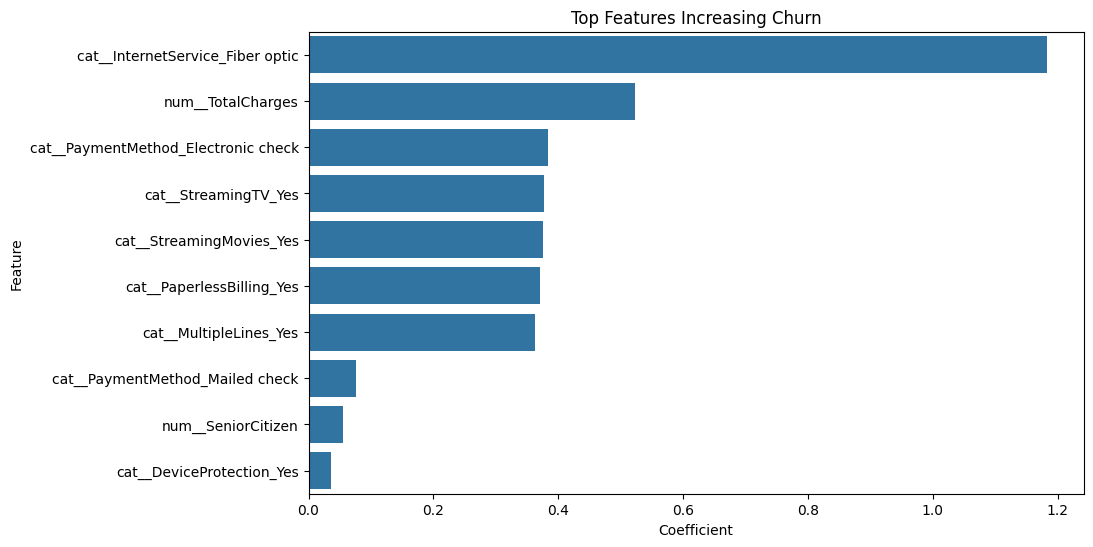

In [57]:
top_positive = (
    importance_df
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Features Increasing Churn"
)

plt.show()

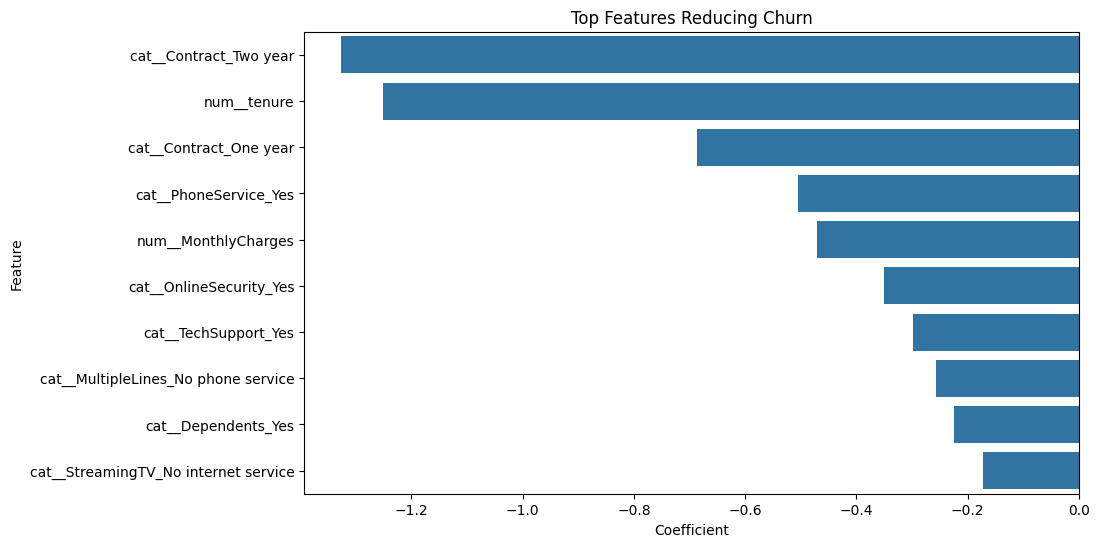

In [58]:
top_negative = (
    importance_df
    .sort_values(
        by="Coefficient"
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Features Reducing Churn"
)

plt.show()

In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Accuracy Scores:")
print(cv_scores)

print("Mean Accuracy:")
print(cv_scores.mean())

CV Accuracy Scores:
[0.83141083 0.80124224 0.80567879 0.79148181 0.79218472]
Mean Accuracy:
0.8043996778570877


In [64]:
from sklearn.model_selection import cross_val_score

f1_scores = cross_val_score(
    lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("CV F1 Scores:")
print(f1_scores)

print("Mean F1:")
print(f1_scores.mean())

CV F1 Scores:
[0.77095652 0.72585269 0.73434488 0.71980864 0.72125528]
Mean F1:
0.7344436031633043


In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [83]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [
        None,
        "balanced"
    ]
}

In [84]:
grid = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    cv=5,
    scoring=f1_scorer,
    n_jobs=-1,
    error_score="raise"
)

In [85]:
grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=Yes)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callable

In [86]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV F1 Score:")
print(grid.best_score_)

Best Parameters:
{'C': 0.1, 'class_weight': 'balanced'}

Best CV F1 Score:
0.6332791312211126


In [87]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(
    X_test_processed
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_best
    )
)

print(
    "Confusion Matrix:\n",
    confusion_matrix(
        y_test,
        y_pred_best
    )
)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

Accuracy: 0.7423704755145494
Confusion Matrix:
 [[753 282]
 [ 81 293]]
              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [88]:
y_prob = best_lr.predict_proba(
    X_test_processed
)[:, 1]

In [89]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [90]:
thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

results = []

for t in thresholds:

    y_pred_threshold = (
        y_prob >= t
    ).astype(int)

    precision = precision_score(
        y_test_xgb,
        y_pred_threshold
    )

    recall = recall_score(
        y_test_xgb,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test_xgb,
        y_pred_threshold
    )

    results.append([
        t,
        precision,
        recall,
        f1
    ])

In [91]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Threshold,Precision,Recall,F1
0,0.30,0.429988,0.927807,0.587638
1,0.35,0.445178,0.901070,0.595933
2,0.40,0.470333,0.868984,0.610329
3,0.45,0.482919,0.831551,0.611002
4,0.50,0.509565,0.783422,0.617492
5,0.55,0.530075,0.754011,0.622517
6,0.60,0.542620,0.697861,0.610526


In [120]:
import joblib

In [121]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [122]:
joblib.dump(
    best_lr,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [123]:
import os

os.listdir("../models")

['churn_model.pkl', 'preprocessor.pkl']